#Análise do dataset de tubercolose

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


DATASET_INFO = {
    "nome": "Dataset de Tuberculose",
    "link": "https://dados.gov.br/dados/conjuntos-dados/dados-tuberculose",
    "orgao": "Estado de Minas Gerais",
    "descricao": '''
    A tuberculose (TB) é uma doença crônica, transmissível e de notificação compulsória. 
    O acompanhamento de indicadores importantes como incidência, mortalidade e cura, entre outros epidemiológicos e operacionais, possibilitam traçar um panorama da TB no território.
''',
    "variaveis_importantes": {
        "nu_ano": "Ano de notificação do caso de tuberculose",
        "nu_idade_n": "Idade do paciente",
        "tratamento": "Tipo de tratamento recebido pelo paciente",
        "forma": "Forma clínica da tuberculose (pulmonar, extrapulmonar, etc.)",
    }
}

dados_tb = "dados_tuberculose.csv"
df_tb = pd.read_csv(dados_tb, encoding="latin1", sep=";")

print("\n===== INFORMAÇÕES DO DATASET =====")
print(f"Nome: {DATASET_INFO['nome']}")
print(f"Link original: {DATASET_INFO['link']}")
print(f"Órgão responsável: {DATASET_INFO['orgao']}")
print(f"Descrição: {DATASET_INFO['descricao']}")

print("\n===== DIMENSÕES =====")
print(f"Número de registros (linhas): {df_tb.shape[0]}")
print(f"Número de colunas: {df_tb.shape[1]}")


===== INFORMAÇÕES DO DATASET =====
Nome: Dataset de Tuberculose
Link original: https://dados.gov.br/dados/conjuntos-dados/dados-tuberculose
Órgão responsável: Estado de Minas Gerais
Descrição: 
    A tuberculose (TB) é uma doença crônica, transmissível e de notificação compulsória. 
    O acompanhamento de indicadores importantes como incidência, mortalidade e cura, entre outros epidemiológicos e operacionais, possibilitam traçar um panorama da TB no território.


===== DIMENSÕES =====
Número de registros (linhas): 77947
Número de colunas: 41


## TIPOS DE DADOS E VALORES AUSENTES

In [3]:
 
print("\n===== TIPOS DE DADOS =====")
print(df_tb.dtypes)

print("\n===== VALORES AUSENTES =====")
print(df_tb.isnull().sum())



===== TIPOS DE DADOS =====
ï»¿id_agravo    object
dt_notific      object
nu_ano           int64
id_municip      object
id_regiona      object
id_unidade       int64
dt_diag         object
nu_idade_n       int64
cs_sexo         object
cs_gestant      object
cs_raca         object
cs_escol_n      object
id_mn_resi      object
id_rg_resi      object
cs_zona         object
agravaids       object
agravalcoo      object
agravdiabe      object
agravdoenc      object
agravoutra      object
agravdroga      object
agravtabac      object
tratamento      object
cultura_es      object
hiv             object
histopatol      object
dt_inic_tr      object
bacilosc_1      object
bacilosc_2      object
bacilosc_3      object
bacilosc_4      object
bacilosc_5      object
bacilosc_6      object
tratsup_at      object
situa_ence      object
dt_encerra      object
pop_liber       object
test_molec      object
test_sensi      object
raiox_tora      object
forma           object
dtype: object

===== VALORES 

# Estásticas Descritivas
### ANÁLISE DA COLUNA 'nu_idade_n' (IDADE)

In [ ]:
# Análise da coluna 'nu_idade_n' (idade)
coluna_idade = df_tb['nu_idade_n']

# Média
media = coluna_idade.mean()
print(f"Média: {media:.2f}")

# Mediana
mediana = coluna_idade.median()
print(f"Mediana: {mediana}")

# Moda
moda = coluna_idade.mode().iloc[0]
print(f"Moda: {moda}")

# Quartis
quartis = coluna_idade.quantile([0.25, 0.5, 0.75])
print("\nQuartis:")
print(quartis)

# Intervalo Interquartil (IQR)
Q1 = quartis[0.25]
Q3 = quartis[0.75]
IQR = Q3 - Q1
print(f"\nIntervalo Interquartil (IQR): {IQR}")


===== ANÁLISE DA COLUNA 'nu_idade_n' (IDADE) =====
Média: 43.66
Mediana: 43.0
Moda: 36

Quartis:
0.25    30.0
0.50    43.0
0.75    56.0
Name: nu_idade_n, dtype: float64

Intervalo Interquartil (IQR): 26.0


## A partir da coluna de idade dos pacientes, podemos calcular as seguintes estatísticas descritivas:
- A idade média dos pacientes é de aproximadamente 43,66 anos. Em geral, os casos de tuberculose estão concentrados em adultos de meia-idade
- A mediana é 43. Como a mediana está próxima da média, isso sugere que a distribuição das idades é aproximadamente simétrica, sem grandes assimetrias.
- A moda é 36 anos, indicando que essa é a idade mais frequente entre os pacientes. Isso pode apontar para uma concentração de casos em adultos jovens.


# Análise de tendências temporais: número de casos por ano


===== NÚMERO DE CASOS POR ANO =====
nu_ano
2010    4644
2011    4754
2012    4451
2013    4429
2014    4476
2015    4286
2016    4424
2017    4458
2018    4562
2019    4704
2020    4234
2021    4481
2022    5269
2023    5913
2024    6213
2025    6400
Name: count, dtype: int64


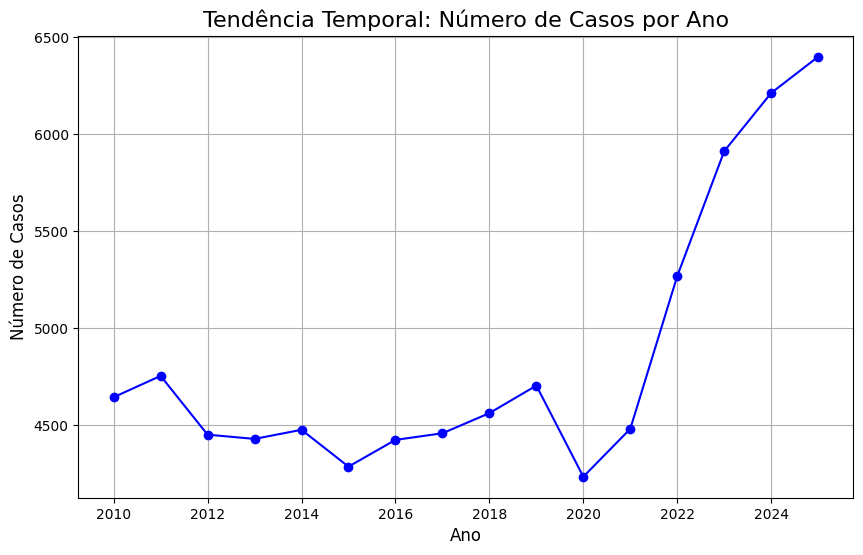

In [4]:
# Análise da coluna 'nu_ano' (ano), excluindo o ano de 2026
casos_por_ano = df_tb[df_tb['nu_ano'] < 2026]['nu_ano'].value_counts().sort_index()

# Exibindo os resultados
print("\n===== NÚMERO DE CASOS POR ANO =====")
print(casos_por_ano)

# Visualização: Gráfico de linhas
plt.figure(figsize=(10, 6))
casos_por_ano.plot(kind='line', marker='o', color='b')
plt.title("Tendência Temporal: Número de Casos por Ano", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Casos", fontsize=12)
plt.grid(True)
plt.show()

### A partir dos resultados apresentados, podemos interpretar que:
- Entre 2010 e 2021, os números flutuam em torno de uma média relativamente estável, com pequenas variações anuais.
- 2020: O número de casos cai para 4234, o menor valor do período analisado. Isso pode estar relacionado a fatores externos, como a pandemia de COVID-19, que pode ter impactado o diagnóstico e a notificação de casos.
- 2022 a 2025: O aumento é mais acentuado, com os casos subindo de 5269 (2022) para 6400 (2025). Esse crescimento pode indicar:
  - Melhorias na detecção e notificação de casos.
  - Um aumento real na incidência da doença devido a fatores como condições socioeconômicas ou interrupções nos programas de controle.
- O aumento significativo a partir de 2022 pode ser um alerta para a necessidade de reforçar as políticas públicas de controle da tuberculose


###  Analise a relação entre os resultados de baciloscopia (bacilosc_1 a bacilosc_6) e o tempo de início do tratamento (dt_diag e dt_inic_tr)

===== TEMPO ENTRE DIAGNÓSTICO E INÍCIO DO TRATAMENTO (em dias) =====
Média: 20.99 dias
Mediana: 0 dias
Mínimo: 0 dias
Máximo: 31343 dias
Registros válidos: 74232

===== DISTRIBUIÇÃO DOS RESULTADOS DA BACILOSCOPIA 1 =====
bacilosc_1
Positiva          22551
NÃ£o realizada    16299
Negativa          10034
NÃ£o se aplica     9773
Name: count, dtype: int64

===== TEMPO MÉDIO (dias) POR RESULTADO DA BACILOSCOPIA 1 =====
                Média (dias)  Mediana (dias)  Quantidade
bacilosc_1                                              
Positiva           19.063545             1.0       22551
NÃ£o realizada     14.867967             0.0       16299
Negativa           22.839745             0.0       10034
NÃ£o se aplica     22.787987             0.0        9773


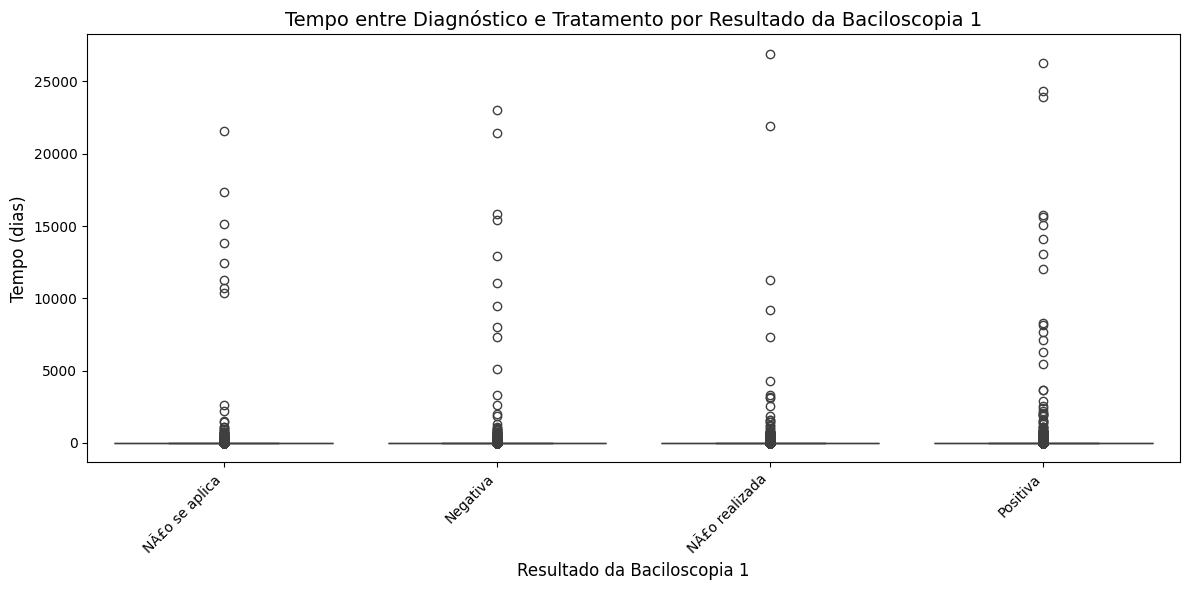

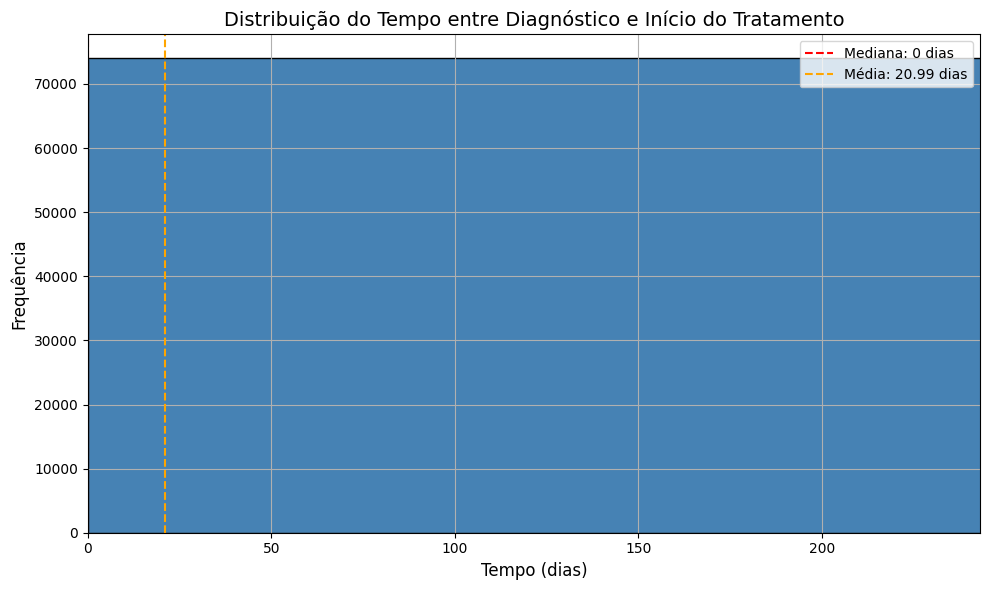

In [ ]:
# Relacionar resultados de baciloscopia com o tempo de início do tratamento

# Converter colunas de data para datetime
df_tb['dt_diag'] = pd.to_datetime(df_tb['dt_diag'], errors='coerce')
df_tb['dt_inic_tr'] = pd.to_datetime(df_tb['dt_inic_tr'], errors='coerce')

# Calcular o tempo (em dias) entre o diagnóstico e o início do tratamento
df_tb['tempo_diag_trat'] = (df_tb['dt_inic_tr'] - df_tb['dt_diag']).dt.days

# Filtrar apenas registros com tempo válido (não nulo e >= 0)
df_valido = df_tb[df_tb['tempo_diag_trat'].notna() & (df_tb['tempo_diag_trat'] >= 0)].copy()

# =====  Estatísticas do tempo entre diagnóstico e tratamento =====
print("===== TEMPO ENTRE DIAGNÓSTICO E INÍCIO DO TRATAMENTO (em dias) =====")
print(f"Média: {df_valido['tempo_diag_trat'].mean():.2f} dias")
print(f"Mediana: {df_valido['tempo_diag_trat'].median():.0f} dias")
print(f"Mínimo: {df_valido['tempo_diag_trat'].min():.0f} dias")
print(f"Máximo: {df_valido['tempo_diag_trat'].max():.0f} dias")
print(f"Registros válidos: {len(df_valido)}")

# ===== Análise da baciloscopia 1 (principal) vs tempo de tratamento =====
colunas_baciloscopia = ['bacilosc_1', 'bacilosc_2', 'bacilosc_3', 'bacilosc_4', 'bacilosc_5', 'bacilosc_6']

# Distribuição dos resultados da baciloscopia 1
print("\n===== DISTRIBUIÇÃO DOS RESULTADOS DA BACILOSCOPIA 1 =====")
print(df_valido['bacilosc_1'].value_counts())

# Tempo médio por resultado da baciloscopia 1
print("\n===== TEMPO MÉDIO (dias) POR RESULTADO DA BACILOSCOPIA 1 =====")
tempo_por_bacilo = df_valido.groupby('bacilosc_1')['tempo_diag_trat'].agg(['mean', 'median', 'count'])
tempo_por_bacilo.columns = ['Média (dias)', 'Mediana (dias)', 'Quantidade']
tempo_por_bacilo = tempo_por_bacilo.sort_values('Quantidade', ascending=False)
print(tempo_por_bacilo)

# ===== Visualização: Boxplot do tempo por resultado da baciloscopia 1 =====
plt.figure(figsize=(12, 6))
# Filtrar apenas categorias com mais de 10 registros para melhor visualização
categorias_relevantes = tempo_por_bacilo[tempo_por_bacilo['Quantidade'] > 10].index
df_plot = df_valido[df_valido['bacilosc_1'].isin(categorias_relevantes)]

sns.boxplot(data=df_plot, x='bacilosc_1', y='tempo_diag_trat')
plt.title("Tempo entre Diagnóstico e Tratamento por Resultado da Baciloscopia 1", fontsize=14)
plt.xlabel("Resultado da Baciloscopia 1", fontsize=12)
plt.ylabel("Tempo (dias)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
 

# ===== Distribuição do tempo entre diagnóstico e tratamento =====
plt.figure(figsize=(10, 6))
df_valido['tempo_diag_trat'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title("Distribuição do Tempo entre Diagnóstico e Início do Tratamento", fontsize=14)
plt.xlabel("Tempo (dias)", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.xlim(0, 50)  # Limita o eixo x de 0 a 50
plt.axvline(df_valido['tempo_diag_trat'].median(), color='red', linestyle='--', label=f"Mediana: {df_valido['tempo_diag_trat'].median():.0f} dias")
plt.axvline(df_valido['tempo_diag_trat'].mean(), color='orange', linestyle='--', label=f"Média: {df_valido['tempo_diag_trat'].mean():.2f} dias")
plt.legend()
plt.tight_layout()
plt.show()

# 6. VISUALIZAÇÕES

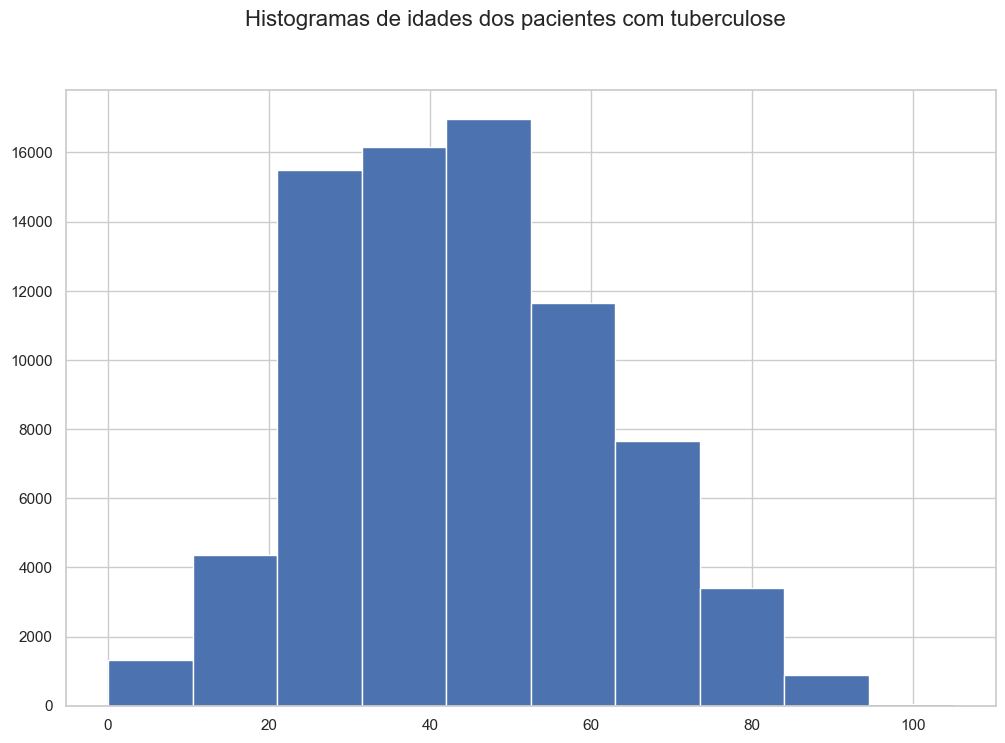

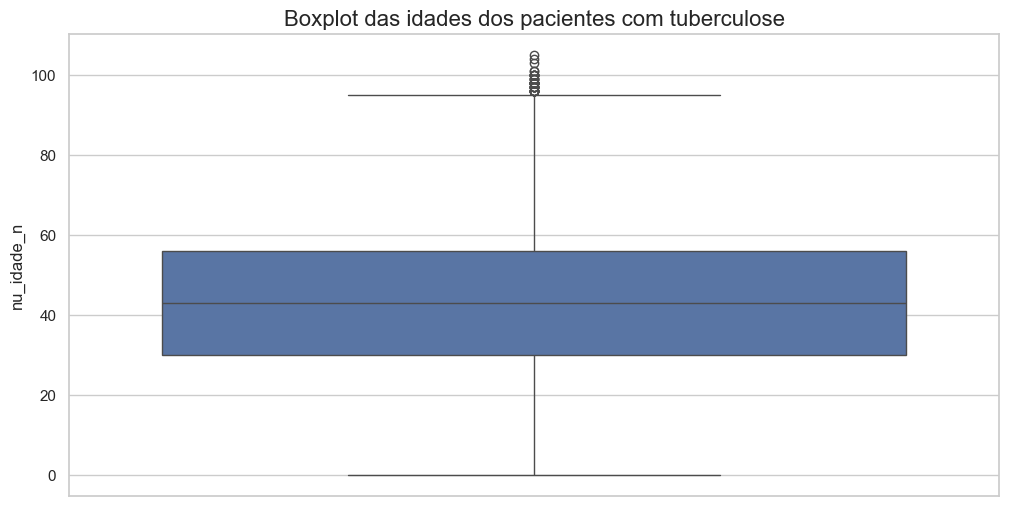

IndexError: tuple index out of range

In [12]:
 
sns.set(style="whitegrid")

# Histogramas
coluna_idade.hist(figsize=(12, 8))
plt.suptitle("Histogramas de idades dos pacientes com tuberculose", fontsize=16)
plt.show()

# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=coluna_idade)
plt.title("Boxplot das idades dos pacientes com tuberculose", fontsize=16)
plt.xticks(rotation=45)
plt.show()

# Scatterplot (se houver pelo menos 2 colunas numéricas)
if coluna_idade.shape[1] >= 2:
    colunas = coluna_idade.columns[:2]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=coluna_idade[colunas[0]],
        y=coluna_idade[colunas[1]]
    )
    plt.title(f"Dispersão: {colunas[0]} vs {colunas[1]}")
    plt.show()

print("\n✅ Análise concluída!")